# Repetition Code

## Imports

In [1]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import stim
import pymatching
import sinter
from typing import List
from ldpc import bposd_decoder, bp_decoder
import importlib, ldpc_decoder
importlib.reload(ldpc_decoder)
from ldpc_decoder import LDPC_Sinter_Decoder

## Circuit Generating Code

In [2]:
def generate_qec_circuit(distance, rounds, noise_prob):
    """
    Inputs:
    Distance is code distance
    rounds is number of rounds of stabilizers
    noise_prob is the probability of bit flip error in physical qubits
    
    Output: returns circuit
    """
    # Put code here:
    circuit = stim.Circuit.generated(
    "repetition_code:memory",
    rounds=rounds,
    distance=distance,
    before_measure_flip_probability=noise_prob)
    # ===
    return circuit

In [3]:
def generate_code_bit_flips(d, noise):
    # SOLUTION ===
    circuit = generate_qec_circuit(
    distance=d,
    rounds=3*d,
    noise_prob=noise)
    # ===
    return circuit

In [4]:
# circuit = generate_code_bit_flips(6,0.1)
# print(circuit)

In [5]:
# You can choose pymatching or vacuous(does nothing), but for other see later
# decoder = ['pymatching']

In [6]:
# circuit.diagram('timeline-svg')

## Threshold

In [7]:
qec_code_tasks = [
    sinter.Task(
        circuit = generate_code_bit_flips(d, noise),
        json_metadata={'d': d, 'r': d , 'p': noise},
    )
    for d in [3,5,7]
    for noise in [0.1, 0.2, 0.3, 0.4, 0.5]
]

# Use this if decoder is pymatching or vacuous
# collected_stats: List[sinter.TaskStats] = sinter.collect(
#     num_workers=1,
#     tasks=qec_code_tasks,
#     decoders=decoder,
#     max_shots=10**5,
#     max_errors= 500
# )

# If custom decoder(bp ones) use this
if __name__ == "__main__":
    custom_decoders = {
        "bposd_0": LDPC_Sinter_Decoder(osd_order=0),
        "bposd_7": LDPC_Sinter_Decoder(osd_order=7),
    }

    collected_stats: List[sinter.TaskStats] = sinter.collect(
        num_workers=4,
        tasks=qec_code_tasks,
        decoders=["bposd_0"],
        custom_decoders=custom_decoders,
        max_shots=10**4,
        max_errors=1000,
    )

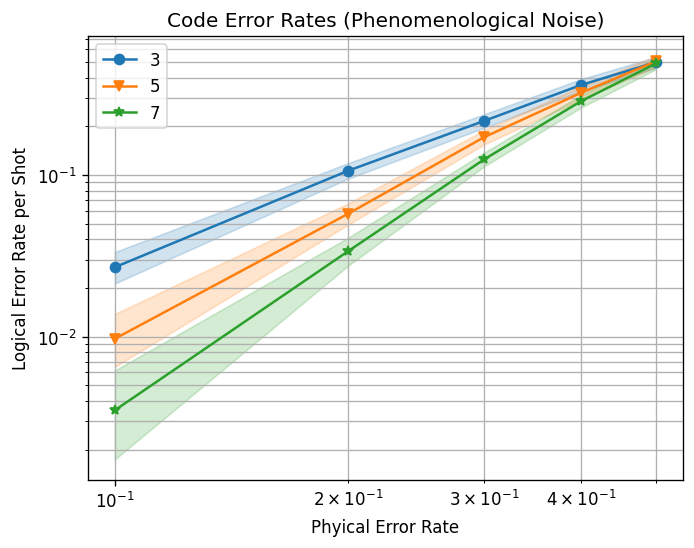

In [8]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Code Error Rates (Phenomenological Noise)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [9]:
print([s.errors for s in collected_stats])

[1008, 1168, 269, 1207, 1160, 97, 1102, 575, 1080, 1174, 337, 35, 1252, 1251, 1139]


## Resources Required to reach $10^{-10}$ bit flip error

In [10]:
bit_flip_prob = 0.01
noise_bias = 1e8
goal_logical_error_rate = bit_flip_prob/noise_bias


# SOLUTION ===

tasks = [
    sinter.Task(
        circuit=generate_code_bit_flips(d, noise),
        json_metadata={'d': d, 'p': noise},
    )
    for d in [3,5,7]
    for noise in [bit_flip_prob]
]

# # Use this if decoder is pymatching or vacuous
# collected_stats: List[sinter.TaskStats] = sinter.collect(
#     num_workers=4,
#     tasks=tasks,
#     decoders=decoder,
#     max_shots=10**7,
#     max_errors=1000,
# )

# If custom decoder use this
if __name__ == "__main__":
    custom_decoders = {
        "bposd_0": LDPC_Sinter_Decoder(osd_order=0),
        "bposd_7": LDPC_Sinter_Decoder(osd_order=7),
    }

    collected_stats: List[sinter.TaskStats] = sinter.collect(
        num_workers=4,
        tasks=tasks,
        decoders=["bposd_0"],
        custom_decoders=custom_decoders,
        max_shots=10**6,
        max_errors=1000,
    )

In [11]:
print([s.errors for s in collected_stats])
# If there are no zeros then continue else increase max shots or take only 3 and 5.

[296, 14, 1]


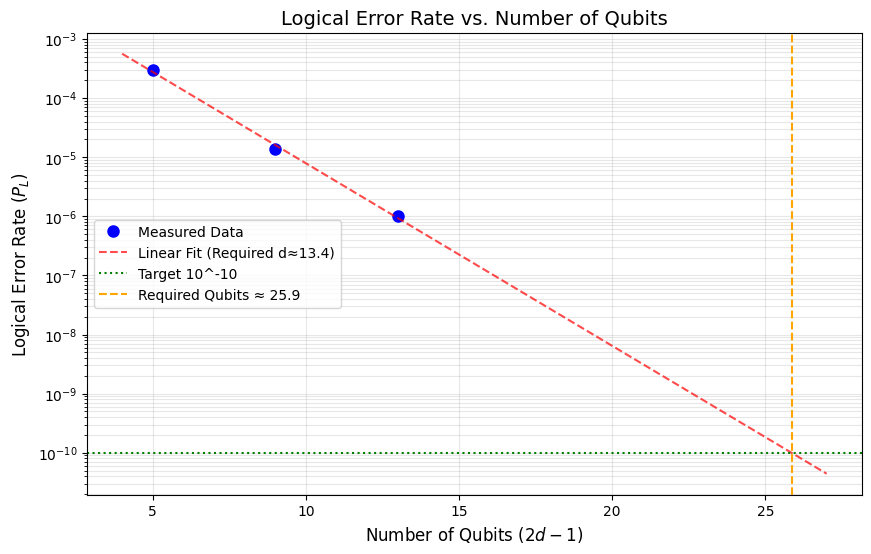

To reach 1e-10, you need d=14 (26 qubits).


In [12]:
data = []
for s in collected_stats:
    if s.errors > 0:
        d = s.json_metadata['d']
        p_logical = s.errors / s.shots
        data.append((d, p_logical))

data.sort()
distances = np.array([d for d, p in data])
p_logical = np.array([p for d, p in data])


log_p = np.log10(p_logical)
slope_d, intercept, _, _, _ = linregress(distances, log_p)

target_p = 1e-10
required_d = (np.log10(target_p) - intercept) / slope_d
required_qubits = 2 * required_d - 1


fig, ax = plt.subplots(figsize=(10, 6))

qubits = 2 * distances - 1
ax.semilogy(qubits, p_logical, 'bo', label='Measured Data', markersize=8)


q_range = np.linspace(min(qubits)-1, np.ceil(required_qubits) + 1, 100)
d_range = (q_range + 1) / 2
p_range = 10**(slope_d * d_range + intercept)
ax.semilogy(q_range, p_range, 'r--', alpha=0.7, label=f'Linear Fit (Required d≈{required_d:.1f})')


ax.axhline(target_p, color='green', linestyle=':', label='Target 10^-10')
ax.axvline(required_qubits, color='orange', linestyle='--', label=f'Required Qubits ≈ {required_qubits:.1f}')


ax.set_title('Logical Error Rate vs. Number of Qubits', fontsize=14)
ax.set_xlabel('Number of Qubits ($2d - 1$)', fontsize=12)
ax.set_ylabel('Logical Error Rate ($P_L$)', fontsize=12)
ax.grid(True, which="both", ls="-", alpha=0.3)
ax.legend()

plt.show()

print(f"To reach 1e-10, you need d={int(np.ceil(required_d))} ({int(np.ceil(required_qubits))} qubits).")

# Save data (Don't forget to update file name)

In [13]:


folder_name = "results"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Created directory: {folder_name}")
    
# 1. Process your results into a simple dictionary of lists
results_to_store = {
    "distances": [s.json_metadata['d'] for s in collected_stats],
    "qubits": [2 * s.json_metadata['d'] - 1 for s in collected_stats],
    "logical_errors": [s.errors / s.shots for s in collected_stats],
    "raw_errors": [s.errors for s in collected_stats],
    "shots": [s.shots for s in collected_stats]
}

# 2. Perform the extrapolation to include in the file
fit_d = np.array([d for d, e in zip(results_to_store["distances"], results_to_store["raw_errors"]) if e > 0])
fit_p = np.array([p for p, e in zip(results_to_store["logical_errors"], results_to_store["raw_errors"]) if e > 0])

slope, intercept, _, _, _ = linregress(fit_d, np.log10(fit_p))
req_d = (np.log10(1e-10) - intercept) / slope
results_to_store["required_d_1e10"] = req_d
results_to_store["required_qubits_1e10"] = 2 * req_d - 1

# 3. Save using Pickle
file_path = os.path.join(folder_name, 'repetition_bp.pkl') 
with open(file_path, 'wb') as f:
    pickle.dump(results_to_store, f)

print(f"Data stored in {file_path}")


Data stored in results/repetition_bp.pkl
